# Submission Comparison
Compares two test-set submission CSVs side by side.
- `test_amo.csv` — AMO (DINOv3 vit-base clean_trainval_43)
- `test_b16_full_3_stages.csv` — BEiT-16 full 3-stage pipeline

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

DIR = Path('.')
CSV_A = DIR / 'test_amo.csv'
# CSV_B = DIR / 'test_b16_full_3_stages_14317936.csv'
# CSV_B = DIR / 'efficientnet_0025.csv'
# CSV_B = DIR / 'dino_3_final_v0_noval_v2.yaml.csv'
CSV_B = DIR / 'dino_full_amo_v1_noval.csv'
LABEL_A = 'AMO (DINOv3)'
LABEL_B = 'Dino-16 no val 2'

df_a = pd.read_csv(CSV_A)
df_b = pd.read_csv(CSV_B)

print(f'Loaded {len(df_a)} rows from {CSV_A.name}')
print(f'Loaded {len(df_b)} rows from {CSV_B.name}')

Loaded 29980 rows from test_amo.csv
Loaded 29980 rows from dino_full_amo_v1_noval.csv


## 1. Coherence checks

In [105]:
issues = []

# Row count
if len(df_a) == len(df_b):
    print(f'✓  Row count matches: {len(df_a)}')
else:
    issues.append(f'✗  Row count mismatch: {len(df_a)} vs {len(df_b)}')
    print(issues[-1])

# Columns
if list(df_a.columns) == list(df_b.columns):
    print(f'✓  Columns match: {list(df_a.columns)}')
else:
    issues.append(f'✗  Column mismatch: {list(df_a.columns)} vs {list(df_b.columns)}')
    print(issues[-1])

# gender column: should all be 'x' for test
for name, df in [(LABEL_A, df_a), (LABEL_B, df_b)]:
    bad = (df['gender'] != 'x').sum()
    if bad == 0:
        print(f'✓  [{name}] gender column is all "x"')
    else:
        issues.append(f'✗  [{name}] {bad} rows with gender != "x"')
        print(issues[-1])

# Filename alignment (same order)
files_match = (df_a['filename'].values == df_b['filename'].values).all()
if files_match:
    print('✓  Filenames match and are in the same order')
else:
    n_diff = (df_a['filename'].values != df_b['filename'].values).sum()
    issues.append(f'✗  {n_diff} filenames differ or are out of order')
    print(issues[-1])
    # Check if same set at least
    set_a, set_b = set(df_a['filename']), set(df_b['filename'])
    only_a = set_a - set_b
    only_b = set_b - set_a
    if only_a or only_b:
        print(f'   Only in A: {len(only_a)} files | Only in B: {len(only_b)} files')
    else:
        print('   Same set of filenames, just different order — will sort-merge for comparison')
        df_a = df_a.sort_values('filename').reset_index(drop=True)
        df_b = df_b.sort_values('filename').reset_index(drop=True)

# NaN / out-of-range
for name, df in [(LABEL_A, df_a), (LABEL_B, df_b)]:
    n_nan = df['FaceOcclusion'].isna().sum()
    n_oob = ((df['FaceOcclusion'] < 0) | (df['FaceOcclusion'] > 1)).sum()
    if n_nan == 0 and n_oob == 0:
        print(f'✓  [{name}] FaceOcclusion: no NaN, all in [0, 1]')
    else:
        msg = f'✗  [{name}] {n_nan} NaN, {n_oob} out-of-range'
        issues.append(msg)
        print(msg)

print()
if not issues:
    print('All checks passed.')
else:
    print(f'{len(issues)} issue(s) found — see above.')

✓  Row count matches: 29980
✓  Columns match: ['filename', 'FaceOcclusion', 'gender']
✓  [AMO (DINOv3)] gender column is all "x"
✓  [Dino-16 no val 2] gender column is all "x"
✓  Filenames match and are in the same order
✓  [AMO (DINOv3)] FaceOcclusion: no NaN, all in [0, 1]
✓  [Dino-16 no val 2] FaceOcclusion: no NaN, all in [0, 1]

All checks passed.


## 2. Summary statistics

In [106]:
pred_a = df_a['FaceOcclusion'].values.astype(float)
pred_b = df_b['FaceOcclusion'].values.astype(float)
diff   = pred_a - pred_b

def describe(arr, label):
    return {
        'Model': label,
        'Mean':  f'{arr.mean():.4f}',
        'Std':   f'{arr.std():.4f}',
        'Var':   f'{arr.var():.6f}',
        'Min':   f'{arr.min():.4f}',
        'p5':    f'{np.percentile(arr, 5):.4f}',
        'p25':   f'{np.percentile(arr, 25):.4f}',
        'Median':f'{np.median(arr):.4f}',
        'p75':   f'{np.percentile(arr, 75):.4f}',
        'p95':   f'{np.percentile(arr, 95):.4f}',
        'Max':   f'{arr.max():.4f}',
        'Skew':  f'{stats.skew(arr):.3f}',
        'Kurt':  f'{stats.kurtosis(arr):.3f}',
    }

stats_df = pd.DataFrame([
    describe(pred_a, LABEL_A),
    describe(pred_b, LABEL_B),
    describe(diff,   f'Diff (A − B)'),
]).set_index('Model')

display(stats_df.T)

Model,AMO (DINOv3),Dino-16 no val 2,Diff (A − B)
Mean,0.1685,0.1690,-0.0005
Std,0.1001,0.0986,0.0140
Var,0.010025,0.009724,0.000196
Min,0.0019,0.0072,-0.1215
p5,0.0187,0.0246,-0.0227
p25,0.0849,0.0855,-0.0079
Median,0.1640,0.1644,-0.0001
p75,0.2450,0.2440,0.0076
p95,0.3380,0.3365,0.0206
Max,0.5247,0.5652,0.0974


## 3. Prediction distributions

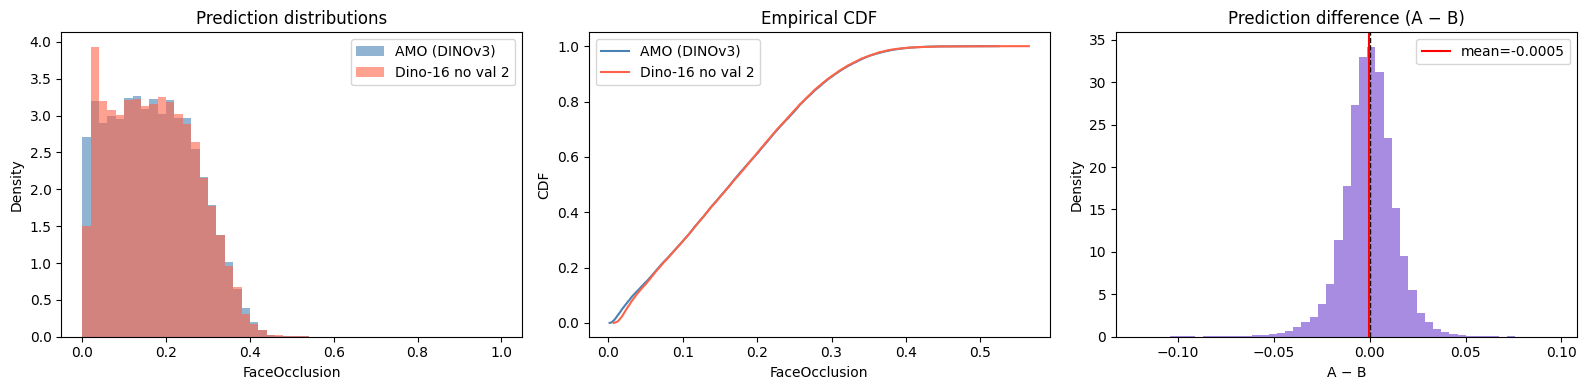

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

bins = np.linspace(0, 1, 51)

# Overlaid histogram
ax = axes[0]
ax.hist(pred_a, bins=bins, alpha=0.6, label=LABEL_A, color='steelblue', density=True)
ax.hist(pred_b, bins=bins, alpha=0.6, label=LABEL_B, color='tomato', density=True)
ax.set_xlabel('FaceOcclusion')
ax.set_ylabel('Density')
ax.set_title('Prediction distributions')
ax.legend()

# CDF
ax = axes[1]
for arr, label, color in [(pred_a, LABEL_A, 'steelblue'), (pred_b, LABEL_B, 'tomato')]:
    sorted_arr = np.sort(arr)
    cdf = np.arange(1, len(sorted_arr) + 1) / len(sorted_arr)
    ax.plot(sorted_arr, cdf, label=label, color=color)
ax.set_xlabel('FaceOcclusion')
ax.set_ylabel('CDF')
ax.set_title('Empirical CDF')
ax.legend()

# Difference histogram
ax = axes[2]
ax.hist(diff, bins=51, color='mediumpurple', alpha=0.8, density=True)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.axvline(diff.mean(), color='red', linewidth=1.5, linestyle='-', label=f'mean={diff.mean():.4f}')
ax.set_xlabel('A − B')
ax.set_ylabel('Density')
ax.set_title('Prediction difference (A − B)')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Scatter: predictions per sample (A vs B)

Pearson r        = 0.9902  (p=0.00e+00)
Spearman ρ       = 0.9901
MAE(A, B)        = 0.0102
RMSE(A, B)       = 0.0140
A predicts more  = 49.6% of samples
B predicts more  = 50.4% of samples


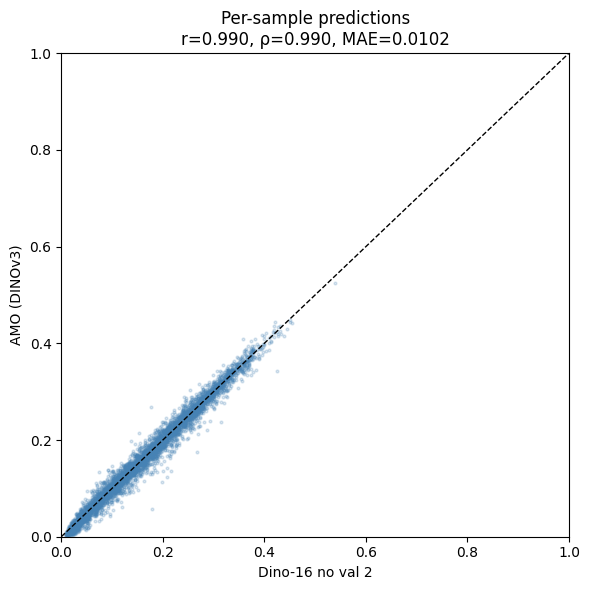

In [108]:
r, pval = stats.pearsonr(pred_a, pred_b)
rho, _ = stats.spearmanr(pred_a, pred_b)
mae    = np.abs(diff).mean()
rmse   = np.sqrt((diff ** 2).mean())

print(f'Pearson r        = {r:.4f}  (p={pval:.2e})')
print(f'Spearman ρ       = {rho:.4f}')
print(f'MAE(A, B)        = {mae:.4f}')
print(f'RMSE(A, B)       = {rmse:.4f}')
print(f'A predicts more  = {(pred_a > pred_b).mean()*100:.1f}% of samples')
print(f'B predicts more  = {(pred_b > pred_a).mean()*100:.1f}% of samples')

fig, ax = plt.subplots(figsize=(6, 6))
# subsample for speed if large
idx = np.random.default_rng(0).choice(len(pred_a), min(5000, len(pred_a)), replace=False)
ax.scatter(pred_b[idx], pred_a[idx], alpha=0.2, s=4, color='steelblue')
lims = [0, 1]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel(LABEL_B)
ax.set_ylabel(LABEL_A)
ax.set_title(f'Per-sample predictions\nr={r:.3f}, ρ={rho:.3f}, MAE={mae:.4f}')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Prediction range buckets — where do models disagree?

In [109]:
n_buckets = 10
bucket_edges = np.linspace(0, 1, n_buckets + 1)
bucket_labels = [f'[{bucket_edges[i]:.1f}, {bucket_edges[i+1]:.1f})' for i in range(n_buckets)]

# Use mean of A and B as bucket key
mean_pred = (pred_a + pred_b) / 2
bucket_idx = np.digitize(mean_pred, bucket_edges[1:-1])

rows = []
for i in range(n_buckets):
    mask = bucket_idx == i
    if mask.sum() == 0:
        continue
    d = diff[mask]
    rows.append({
        'Bucket (avg pred)': bucket_labels[i],
        'N samples': mask.sum(),
        'Mean(A)':  f'{pred_a[mask].mean():.4f}',
        'Mean(B)':  f'{pred_b[mask].mean():.4f}',
        'Mean(A−B)': f'{d.mean():.4f}',
        'Std(A−B)': f'{d.std():.4f}',
        'MAE(A,B)': f'{np.abs(d).mean():.4f}',
    })

display(pd.DataFrame(rows).set_index('Bucket (avg pred)'))

,N samples,Mean(A),Mean(B),Mean(A−B),Std(A−B),"MAE(A,B)"
Bucket (avg pred),,,,,,
"[0.0, 0.1)",8814,0.0509,0.0536,-0.0027,0.0119,0.0091
"[0.1, 0.2)",9562,0.1495,0.1498,-0.0003,0.0154,0.0112
"[0.2, 0.3)",8337,0.2467,0.2459,0.0008,0.0144,0.0105
"[0.3, 0.4)",3072,0.3364,0.3349,0.0015,0.0129,0.0097
"[0.4, 0.5)",191,0.4219,0.4238,-0.0020,0.0161,0.0115
"[0.5, 0.6)",4,0.5177,0.5328,-0.0151,0.0250,0.0201


## 6. Most divergent samples

In [110]:
comparison = pd.DataFrame({
    'filename': df_a['filename'],
    LABEL_A: pred_a,
    LABEL_B: pred_b,
    'abs_diff': np.abs(diff),
    'diff (A-B)': diff,
})

print('=== 20 samples where A predicts MUCH MORE than B ===')
display(comparison.nlargest(20, 'diff (A-B)')[['filename', LABEL_A, LABEL_B, 'diff (A-B)']].reset_index(drop=True))

print()
print('=== 20 samples where B predicts MUCH MORE than A ===')
display(comparison.nsmallest(20, 'diff (A-B)')[['filename', LABEL_A, LABEL_B, 'diff (A-B)']].reset_index(drop=True))

=== 20 samples where A predicts MUCH MORE than B ===


,filename,AMO (DINOv3),Dino-16 no val 2,diff (A-B)
0,database3/database3/m.027tm9b/127-FaceId-0_ali...,0.389431,0.292057,0.097374
1,database3/database3/m.016qrb/72-FaceId-0_align...,0.267221,0.175877,0.091344
2,database3/database3/m.0263q7c/88-FaceId-0_alig...,0.191310,0.109480,0.081830
3,database3/database3/m.01k4f7/71-FaceId-0_align...,0.293774,0.219246,0.074528
4,database3/database3/m.021r4g/55-FaceId-0_align...,0.284731,0.210414,0.074317
5,database3/database3/m.028tvd/91-FaceId-0_align...,0.251717,0.177425,0.074293
6,database3/database3/m.01sh3s_/73-FaceId-1_alig...,0.205206,0.130999,0.074207
7,database3/database3/m.014d3y/100-FaceId-0_alig...,0.183520,0.109447,0.074073
8,database3/database3/m.01zjsv/62-FaceId-0_align...,0.243093,0.176065,0.067028
9,database1/img00010704.webp,0.278027,0.211883,0.066143



=== 20 samples where B predicts MUCH MORE than A ===


,filename,AMO (DINOv3),Dino-16 no val 2,diff (A-B)
0,database3/database3/m.018ft2/78-FaceId-0_align...,0.056307,0.177760,-0.121453
1,database3/database3/m.026s7l/50-FaceId-0_align...,0.134318,0.246962,-0.112644
2,database3/database3/m.0175jl/81-FaceId-0_align...,0.087871,0.200194,-0.112324
3,database3/database3/m.01k49p/77-FaceId-0_align...,0.237101,0.341980,-0.104878
4,database3/database3/m.0198j2/42-FaceId-0_align...,0.203195,0.306907,-0.103712
5,database3/database3/m.014d3/1-FaceId-0_align.webp,0.057180,0.160846,-0.103666
6,database3/database3/m.01nhzl/64-FaceId-0_align...,0.063235,0.164023,-0.100788
7,database3/database3/m.016x2n/10-FaceId-0_align...,0.079842,0.179948,-0.100106
8,database3/database3/m.015cbq/70-FaceId-0_align...,0.149303,0.248698,-0.099395
9,database3/database3/m.01w5pnq/93-FaceId-0_alig...,0.130144,0.229157,-0.099013


## 7. Approximate competition metric on validation (if val CSVs available)

The test set has no ground truth, so the competition score cannot be computed directly.
If you have a `val.csv` for each model (with columns `FaceOcclusion`, `pred`, `gender`),
point the paths below to compute exact competition scores.

In [111]:
import sys
sys.path.insert(0, str(Path('..')))

try:
    from src.metrics import metric_fn
    metrics_available = True
except ImportError:
    metrics_available = False
    print('Could not import src.metrics — skipping val score computation')

# Set these to your val.csv paths if available
VAL_A = None   # e.g. Path('../submission/some_run_a/val.csv')
VAL_B = None   # e.g. Path('../submission/some_run_b/val.csv')

if metrics_available and VAL_A and VAL_B:
    import torch
    results = {}
    for name, path in [(LABEL_A, VAL_A), (LABEL_B, VAL_B)]:
        v = pd.read_csv(path)
        preds  = torch.tensor(v['pred'].values, dtype=torch.float32)
        labels = torch.tensor(v['FaceOcclusion'].values, dtype=torch.float32)
        gender = torch.tensor(v['gender'].values, dtype=torch.float32)
        score = metric_fn(preds, labels, gender).item()
        results[name] = score
        print(f'[{name}] val score = {score:.6f}')
    if len(results) == 2:
        delta = list(results.values())[0] - list(results.values())[1]
        print(f'Δ score (A − B) = {delta:+.6f}  ({'A is better' if delta < 0 else 'B is better'})')
else:
    print('Set VAL_A and VAL_B paths to compute competition scores on validation.')

Set VAL_A and VAL_B paths to compute competition scores on validation.


## 8. Score surrogate on test — weighted variance of predictions

Since test has no GT, here's a quick proxy: what fraction of predictions fall in the high-occlusion range (where the competition weight `w = 1/30 + GT` is largest).

In [112]:
thresholds = [0.1, 0.2, 0.3, 0.5, 0.7]
rows = []
for t in thresholds:
    rows.append({
        'Threshold': f'> {t}',
        f'{LABEL_A} (%)': f'{(pred_a > t).mean()*100:.2f}',
        f'{LABEL_B} (%)': f'{(pred_b > t).mean()*100:.2f}',
    })
print('Fraction of test samples with high occlusion predictions:')
display(pd.DataFrame(rows).set_index('Threshold'))

# Approximate competition weight-distribution (using predictions as proxy for GT)
print()
for arr, label in [(pred_a, LABEL_A), (pred_b, LABEL_B)]:
    w = 1/30 + arr          # weight if pred ≈ GT
    mean_w = w.mean()
    print(f'[{label}] mean competition weight (proxy) = {mean_w:.4f}')

Fraction of test samples with high occlusion predictions:


,AMO (DINOv3) (%),Dino-16 no val 2 (%)
Threshold,,
> 0.1,70.53,70.56
> 0.2,38.85,38.61
> 0.3,11.09,10.84
> 0.5,0.01,0.02
> 0.7,0.00,0.00



[AMO (DINOv3)] mean competition weight (proxy) = 0.2018
[Dino-16 no val 2] mean competition weight (proxy) = 0.2023


## 9. DINO pipeline weights: iw, pi, gw — train / val / test

Replicates exactly the weight computation from `src/dino/utils.py` and `src/data/data_utils.py`.

- **iw** (importance weight): Laplacian ratio `(test_dist + α/N) / (train_dist + α/N)` per occlusion bin — upweights underrepresented bins relative to test distribution
- **pi** (label weight): `1/30 + FaceOcclusion` — the competition's own per-sample weight, grows linearly with occlusion
- **gw** (gender weight): per-(bin × gender) balancing so that female and male contribute equally across the occlusion range

Test set has no labels → iw = pi = gw = 1 for all samples.

In [113]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path('..').resolve()))

from src.config import CSV_DIR, SCREENSHOT_PATH
from src.data.data_stats import get_test_distribution_from_screenshot, N_BINS
from src.data.data_utils import compute_gender_weights, N_BINS_GENDER, ALPHA_SMOOTH

# ── Config ───────────────────────────────────────────────────────────────────
SMOOTH_ALPHA = 0   # matches dino_cnn.yaml / dino_cnn_ft.yaml

# ── Load raw data + split (identical to pipeline: random_state=42, 80/20) ────
df_all = pd.read_csv(CSV_DIR / "train.csv").dropna().reset_index(drop=True)
df_train_raw, df_val_raw = train_test_split(df_all, test_size=0.2, random_state=42, shuffle=True)
df_train_raw = df_train_raw.reset_index(drop=True)
df_val_raw   = df_val_raw.reset_index(drop=True)

# ── iw: Laplacian importance weights ─────────────────────────────────────────
def compute_iw(df, alpha=SMOOTH_ALPHA):
    bins = np.linspace(0, 1, N_BINS + 1)
    n_ech = len(df)
    train_hist, _ = np.histogram(df["FaceOcclusion"], bins=bins)
    train_hist = train_hist / train_hist.sum()
    test_dist  = get_test_distribution_from_screenshot(SCREENSHOT_PATH, n_bins=N_BINS)
    ratio      = (test_dist + alpha / n_ech) / (1e-6 + train_hist + alpha / n_ech)
    y          = df["FaceOcclusion"].values
    bin_idx    = np.clip(np.digitize(y, bins) - 1, 0, N_BINS - 1)
    return ratio[bin_idx], ratio, test_dist, train_hist

iw_train, ratio_train, test_dist, hist_train = compute_iw(df_train_raw)
iw_val,   ratio_val,   _,         hist_val   = compute_iw(df_val_raw)

# ── pi: label weights (competition formula) ───────────────────────────────────
pi_train = 1/30 + df_train_raw["FaceOcclusion"].values
pi_val   = 1/30 + df_val_raw["FaceOcclusion"].values

# ── gw: gender-balancing weights ─────────────────────────────────────────────
def compute_gw(df):
    y  = torch.tensor(df["FaceOcclusion"].values, dtype=torch.float32)
    g  = torch.tensor(df["gender"].values,        dtype=torch.float32)
    W_F, W_M    = compute_gender_weights(y, g)
    bins_gender = torch.linspace(0, 1, N_BINS_GENDER + 1)
    bin_idx     = (torch.bucketize(y, bins_gender, right=False) - 1).clamp(0, N_BINS_GENDER - 1)
    gw          = torch.where(g == 0.0, W_F[bin_idx], W_M[bin_idx]).numpy()
    return gw, g.numpy(), W_F.numpy(), W_M.numpy()

gw_train, g_train, W_F_train, W_M_train = compute_gw(df_train_raw)
gw_val,   g_val,   W_F_val,   W_M_val   = compute_gw(df_val_raw)

y_train = df_train_raw["FaceOcclusion"].values
y_val   = df_val_raw["FaceOcclusion"].values

print(f"Train: {len(df_train_raw):,} samples  |  Val: {len(df_val_raw):,} samples")
print(f"iw  train  — mean={iw_train.mean():.3f}  std={iw_train.std():.3f}  "
      f"range=[{iw_train.min():.3f}, {iw_train.max():.3f}]")
print(f"iw  val    — mean={iw_val.mean():.3f}  std={iw_val.std():.3f}  "
      f"range=[{iw_val.min():.3f}, {iw_val.max():.3f}]")
print(f"pi  train  — mean={pi_train.mean():.3f}  std={pi_train.std():.3f}  "
      f"range=[{pi_train.min():.3f}, {pi_train.max():.3f}]")
print(f"gw  train  — mean={gw_train.mean():.3f}  std={gw_train.std():.3f}  "
      f"range=[{gw_train.min():.3f}, {gw_train.max():.3f}]")

Train: 80,000 samples  |  Val: 20,000 samples
iw  train  — mean=1.000  std=0.989  range=[0.006, 5.249]
iw  val    — mean=1.000  std=1.002  range=[0.005, 9.819]
pi  train  — mean=0.116  std=0.087  range=[0.033, 1.033]
gw  train  — mean=0.997  std=0.762  range=[0.569, 4.129]


/var/folders/r6/vjff12js0_3d1j8lxkmmhthr0000gn/T/ipykernel_47985/3514100113.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


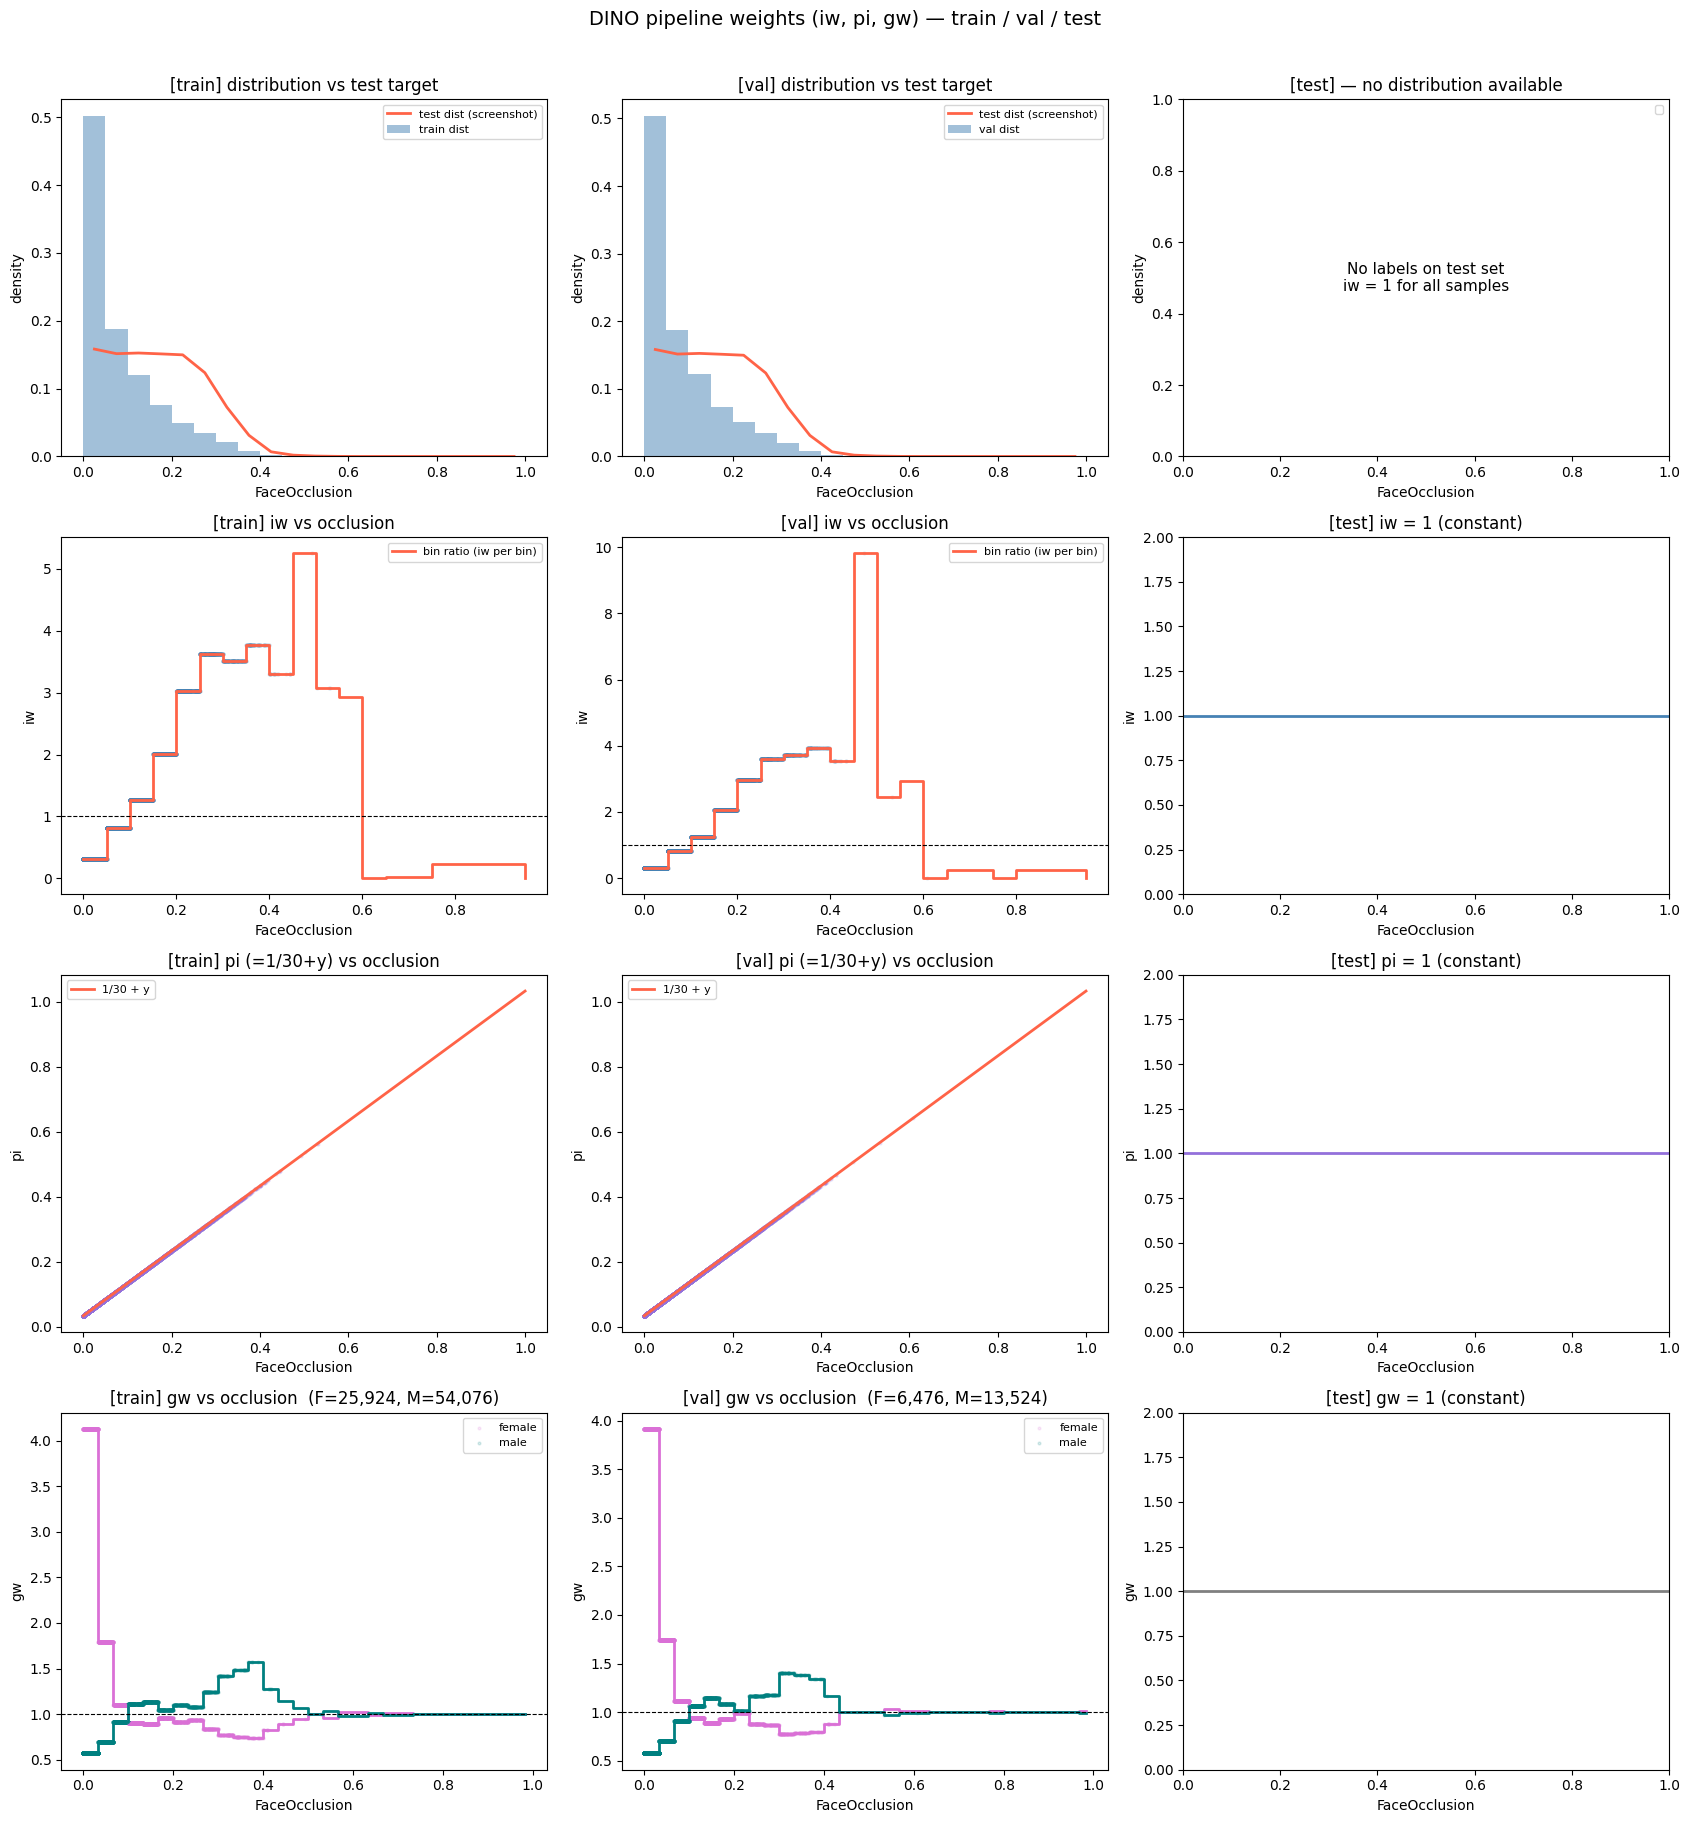

In [114]:
bin_centers = np.linspace(0, 1, N_BINS + 1)[:-1] + 0.5 / N_BINS
bins_iw     = np.linspace(0, 1, N_BINS + 1)
bins_gw     = np.linspace(0, 1, N_BINS_GENDER + 1)
gc_gw       = (bins_gw[:-1] + bins_gw[1:]) / 2

SUBSAMPLE = 8000   # scatter point cap

fig, axes = plt.subplots(4, 3, figsize=(17, 18))
fig.suptitle("DINO pipeline weights (iw, pi, gw) — train / val / test", fontsize=14, y=1.01)

for col, (split, y, iw, pi, gw, g, W_F, W_M, hist) in enumerate([
    ("train", y_train, iw_train, pi_train, gw_train, g_train, W_F_train, W_M_train, hist_train),
    ("val",   y_val,   iw_val,   pi_val,   gw_val,   g_val,   W_F_val,   W_M_val,   hist_val),
    ("test (no labels)", None, None, None, None, None, None, None, None),
]):
    # ── Row 0: test distribution vs split distribution ────────────────────────
    ax = axes[0, col]
    if y is not None:
        ax.bar(bin_centers, hist, width=1/N_BINS, alpha=0.5, color='steelblue', label=f'{split} dist')
        ax.plot(bin_centers, test_dist, color='tomato', linewidth=2, label='test dist (screenshot)')
        ax.set_title(f"[{split}] distribution vs test target")
    else:
        ax.text(0.5, 0.5, "No labels on test set\niw = 1 for all samples",
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title("[test] — no distribution available")
    ax.set_xlabel("FaceOcclusion"); ax.set_ylabel("density")
    ax.legend(fontsize=8)

    # ── Row 1: iw per sample ─────────────────────────────────────────────────
    ax = axes[1, col]
    if y is not None:
        rng = np.random.default_rng(0)
        idx = rng.choice(len(y), min(SUBSAMPLE, len(y)), replace=False)
        ax.scatter(y[idx], iw[idx], alpha=0.15, s=4, color='steelblue')
        # binned mean line
        ax.step(bins_iw[:-1], ratio_train if col == 0 else ratio_val,
                where='post', color='tomato', linewidth=2, label='bin ratio (iw per bin)')
        ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f"[{split}] iw vs occlusion")
        ax.set_ylabel("iw")
        ax.legend(fontsize=8)
    else:
        ax.axhline(1, color='steelblue', linewidth=2)
        ax.set_ylim(0, 2); ax.set_title("[test] iw = 1 (constant)")
        ax.set_ylabel("iw")
    ax.set_xlabel("FaceOcclusion")

    # ── Row 2: pi per sample ──────────────────────────────────────────────────
    ax = axes[2, col]
    if y is not None:
        ax.scatter(y[idx], pi[idx], alpha=0.15, s=4, color='mediumpurple')
        x_line = np.linspace(0, 1, 100)
        ax.plot(x_line, 1/30 + x_line, color='tomato', linewidth=2, label='1/30 + y')
        ax.set_title(f"[{split}] pi (=1/30+y) vs occlusion")
        ax.legend(fontsize=8)
    else:
        ax.axhline(1, color='mediumpurple', linewidth=2)
        ax.set_ylim(0, 2); ax.set_title("[test] pi = 1 (constant)")
    ax.set_xlabel("FaceOcclusion"); ax.set_ylabel("pi")

    # ── Row 3: gw per sample, by gender ──────────────────────────────────────
    ax = axes[3, col]
    if y is not None and g is not None:
        f_mask = g[idx] == 0.0
        m_mask = g[idx] == 1.0
        ax.scatter(y[idx][f_mask], gw[idx][f_mask], alpha=0.15, s=4, color='orchid',  label='female')
        ax.scatter(y[idx][m_mask], gw[idx][m_mask], alpha=0.15, s=4, color='teal',    label='male')
        ax.step(gc_gw, W_F, where='mid', color='orchid', linewidth=2)
        ax.step(gc_gw, W_M, where='mid', color='teal',   linewidth=2)
        ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
        n_f = (g == 0.0).sum(); n_m = (g == 1.0).sum()
        ax.set_title(f"[{split}] gw vs occlusion  (F={n_f:,}, M={n_m:,})")
        ax.legend(fontsize=8)
    else:
        ax.axhline(1, color='gray', linewidth=2)
        ax.set_ylim(0, 2); ax.set_title("[test] gw = 1 (constant)")
    ax.set_xlabel("FaceOcclusion"); ax.set_ylabel("gw")

plt.tight_layout()
plt.show()

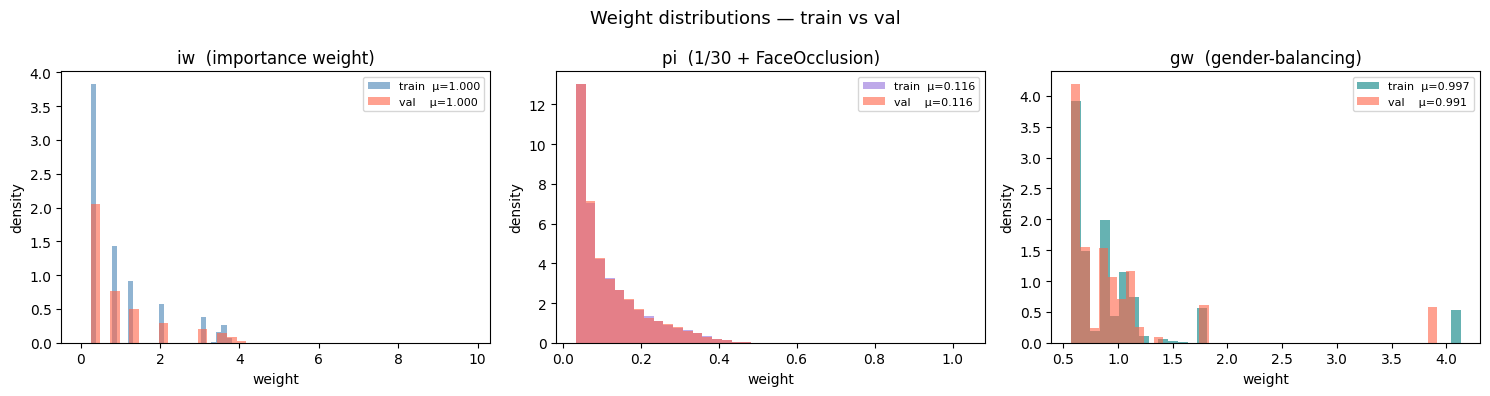

mean     std     min     max     p25     p50     p75
weight split                                                        
iw     train  1.0000  0.9887  0.0060  5.2489  0.3157  0.3157  1.2648
       val    1.0000  1.0016  0.0045  9.8189  0.3145  0.3145  1.2530
pi     train  0.1162  0.0866  0.0333  1.0333  0.0512  0.0831  0.1561
       val    0.1156  0.0861  0.0333  1.0333  0.0513  0.0828  0.1556
gw     train  0.9974  0.7625  0.5689  4.1293  0.5689  0.8381  1.0796
       val    0.9908  0.7260  0.5731  3.9180  0.5731  0.8679  1.0644

In [115]:
# Weight distributions: iw, pi, gw histograms (train vs val)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Weight distributions — train vs val", fontsize=13)

for ax, (w_tr, w_va, title, color) in zip(axes, [
    (iw_train, iw_val, "iw  (importance weight)",   'steelblue'),
    (pi_train, pi_val, "pi  (1/30 + FaceOcclusion)", 'mediumpurple'),
    (gw_train, gw_val, "gw  (gender-balancing)",     'teal'),
]):
    ax.hist(w_tr, bins=40, alpha=0.6, density=True, color=color,   label=f'train  μ={w_tr.mean():.3f}')
    ax.hist(w_va, bins=40, alpha=0.6, density=True, color='tomato', label=f'val    μ={w_va.mean():.3f}')
    ax.set_title(title); ax.set_xlabel("weight"); ax.set_ylabel("density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary table
rows = []
for name, w_tr, w_va in [
    ("iw",  iw_train,  iw_val),
    ("pi",  pi_train,  pi_val),
    ("gw",  gw_train,  gw_val),
]:
    for split, w in [("train", w_tr), ("val", w_va)]:
        rows.append({
            "weight": name, "split": split,
            "mean": f"{w.mean():.4f}", "std":  f"{w.std():.4f}",
            "min":  f"{w.min():.4f}", "max":  f"{w.max():.4f}",
            "p25":  f"{np.percentile(w, 25):.4f}",
            "p50":  f"{np.percentile(w, 50):.4f}",
            "p75":  f"{np.percentile(w, 75):.4f}",
        })
display(pd.DataFrame(rows).set_index(["weight", "split"]))

In [116]:
iw_train.argmin()

np.int64(4294)

In [117]:
import torch
from src.dino.run_unfreeze import build_dino_ft_model
from src.dino.utils import load_config

# Reconstruct the model architecture from the same config used during training
cfg = load_config("2026-06-09_22-28-19_dino_unfreeze_v1.yaml")  # or pass the dict directly

model = build_dino_ft_model(cfg)       # builds backbone + PatchCNN head
model.load_state_dict(
    torch.load("../checkpoints/selected/2026-06-09_22-28-19_dino_unfreeze_v1.pt",
               map_location="cpu")
)
model.eval()

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 27947.02it/s]

Head loaded from ../checkpoints/selected/dino_cnn_2026-06-09_20-48-20_best_exp_pad_v3.pt


RuntimeError: Error(s) in loading state_dict for DinoFinetuneModel:
	Missing key(s) in state_dict: "backbone.model.layer.0.norm1.weight", "backbone.model.layer.0.norm1.bias", "backbone.model.layer.0.attention.k_proj.weight", "backbone.model.layer.0.attention.v_proj.weight", "backbone.model.layer.0.attention.v_proj.bias", "backbone.model.layer.0.attention.q_proj.weight", "backbone.model.layer.0.attention.q_proj.bias", "backbone.model.layer.0.attention.o_proj.weight", "backbone.model.layer.0.attention.o_proj.bias", "backbone.model.layer.0.layer_scale1.lambda1", "backbone.model.layer.0.norm2.weight", "backbone.model.layer.0.norm2.bias", "backbone.model.layer.0.mlp.up_proj.weight", "backbone.model.layer.0.mlp.up_proj.bias", "backbone.model.layer.0.mlp.down_proj.weight", "backbone.model.layer.0.mlp.down_proj.bias", "backbone.model.layer.0.layer_scale2.lambda1", "backbone.model.layer.1.norm1.weight", "backbone.model.layer.1.norm1.bias", "backbone.model.layer.1.attention.k_proj.weight", "back

In [ ]:
# iw = np.concat([iw_train, iw_val])
# pi = np.concat([pi_train, pi_val])

# y_true = [df_train_raw["FaceOcclusion"].values, df_val_raw["FaceOcclusion"].values]
# y_pred = 

In [ ]:
# w  = (iw * pi).view(-1)
# se = ((y_true - y_pred) ** 2).view(-1)
# g  = gender.view(-1)
# mask_f = g == 0.0
# mask_m = g == 1.0
# err_f = torch.sum(w[mask_f] * se[mask_f]) / (torch.sum(w[mask_f]) + EPS)
# err_m = torch.sum(w[mask_m] * se[mask_m]) / (torch.sum(w[mask_m]) + EPS)
# return (err_f + err_m) / 2 + torch.abs(err_f - err_m), err_f, err_m